In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.pipeline import FeatureUnion
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
df = pd.read_csv("C:\\Users\\sobha\\Downloads\\Phishing_Email.csv\\Phishing_Email.csv")
df.describe()

,Unnamed: 0
count,18650.000000
mean,9325.154477
std,5384.327293
min,0.000000
25%,4662.250000
50%,9325.500000
75%,13987.750000
max,18650.000000


In [3]:
df.head(10)

,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email
5,5,global risk management operations sally congra...,Safe Email
6,6,"On Sun, Aug 11, 2002 at 11:17:47AM +0100, wint...",Safe Email
7,7,"entourage , stockmogul newsletter ralph velez ...",Phishing Email
8,8,"we owe you lots of money dear applicant , afte...",Phishing Email
9,9,re : coastal deal - with exxon participation u...,Safe Email


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18650 entries, 0 to 18649
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  18650 non-null  int64 
 1   Email Text  18634 non-null  object
 2   Email Type  18650 non-null  object
dtypes: int64(1), object(2)
memory usage: 437.2+ KB


In [5]:
df.dropna(inplace=True)

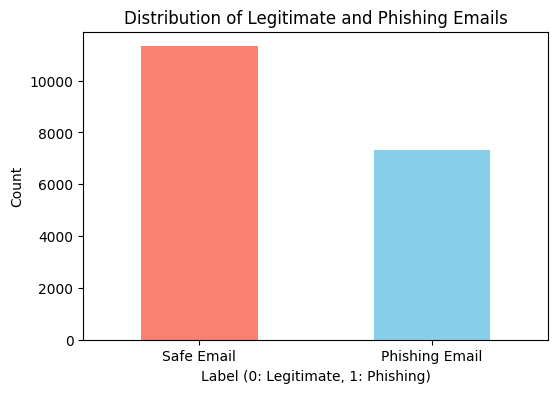

In [6]:
plt.figure(figsize=(6, 4))
df['Email Type'].value_counts().plot(kind='bar', color=['salmon', 'skyblue'])
plt.title('Distribution of Legitimate and Phishing Emails')
plt.xlabel('Label (0: Legitimate, 1: Phishing)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [7]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as stop_words

def clean_text(text):
    text = re.sub(r'\W', ' ', text)  
    text = text.lower()  
    text = text.split()  
    text = [word for word in text if word not in stop_words]  
    return ' '.join(text)

In [8]:
x= df['Email Text'].apply(clean_text).tolist()
y = df['Email Type'].map({'Safe Email':0, 'Phishing Email': 1})
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [9]:
# TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

# Logistic Regression Pipeline
logreg_pipeline = Pipeline([
    ('tfidf', tfidf),
    ('clf', LogisticRegression(solver='liblinear', random_state=42))
])

# Random Forest Pipeline
rf_pipeline = Pipeline([
    ('tfidf', tfidf),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Naive Bayes Pipeline
nb_pipeline = Pipeline([
    ('tfidf', tfidf),
    ('clf', MultinomialNB())
])

# Support Vector Machine Pipeline
svm_pipeline = Pipeline([
    ('tfidf', tfidf),
    ('clf', SVC(probability=True, kernel='linear', random_state=42))
])

# Gradient Boosting Pipeline
gb_pipeline = Pipeline([
    ('tfidf', tfidf),
    ('clf', GradientBoostingClassifier(n_estimators=100, random_state=42))
])


In [10]:
# Create a voting classifier
voting_clf = VotingClassifier(
    estimators=[
        ('logreg', logreg_pipeline),
        ('random_forest', rf_pipeline),
        ('naive_bayes', nb_pipeline),
        ('svm', svm_pipeline),
        ('gradient_boosting', gb_pipeline)
    ],
    voting='soft'
)

# Train the voting classifier
voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('logreg',
                              Pipeline(steps=[('tfidf',
                                               TfidfVectorizer(max_features=5000,
                                                               stop_words='english')),
                                              ('clf',
                                               LogisticRegression(random_state=42,
                                                                  solver='liblinear'))])),
                             ('random_forest',
                              Pipeline(steps=[('tfidf',
                                               TfidfVectorizer(max_features=5000,
                                                               stop_words='english')),
                                              ('clf',
                                               RandomForestClassifier(random_state=42))])),
                             ('naive_bayes...
                                              ('clf', MultinomialNB())])),
                             ('svm',
                              Pipeline(steps=[('tfidf',
                                               TfidfVectorizer(max_features=5000,
                                                               stop_words='english')),
                                              ('clf',
                                               SVC(kernel='linear',
                                                   probability=True,
                                                   random_state=42))])),
                             ('gradient_boosting',
                              Pipeline(steps=[('tfidf',
                                               TfidfVectorizer(max_features=5000,
                                                               stop_words='english')),
                                              ('clf',
                                               GradientBoostingClassifier(random_state=42))]))],
                 voting='soft')

In [11]:
y_pred = voting_clf.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9702173329755835

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.96      0.97      2209
           1       0.95      0.98      0.96      1518

    accuracy                           0.97      3727
   macro avg       0.97      0.97      0.97      3727
weighted avg       0.97      0.97      0.97      3727


Confusion Matrix:
 [[2130   79]
 [  32 1486]]


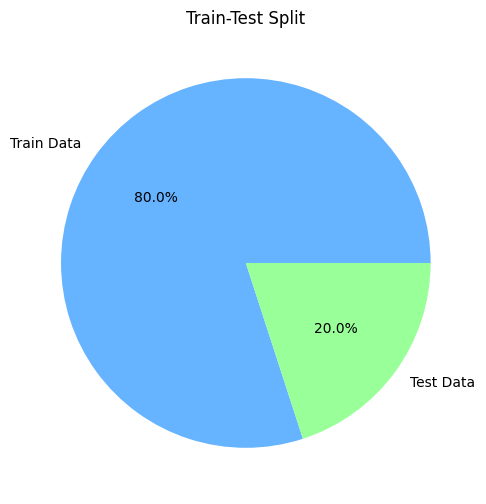

In [12]:
# Pie chart of Train-Test Split
train_size = len(X_train)
test_size = len(X_test)

plt.figure(figsize=(6, 6))
plt.pie([train_size, test_size], labels=['Train Data', 'Test Data'], autopct='%1.1f%%', colors=['#66b3ff','#99ff99'])
plt.title('Train-Test Split')
plt.show()


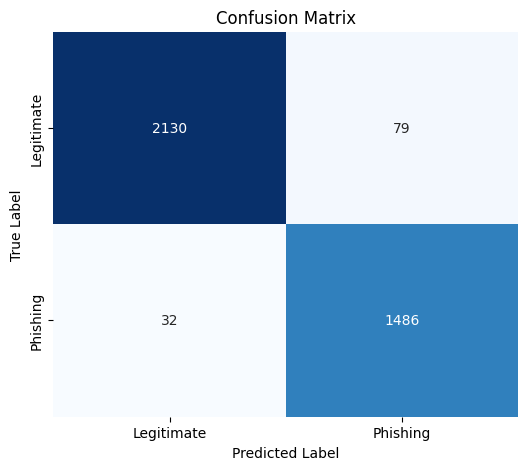

In [13]:
# Generate predictions
y_pred = voting_clf.predict(X_test)

# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Legitimate', 'Phishing'], yticklabels=['Legitimate', 'Phishing'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [14]:
# List to store the models and their names
models = {
    'Logistic Regression': logreg_pipeline,
    'Random Forest': rf_pipeline,
    'Naive Bayes': nb_pipeline,
    'Support Vector Machine': svm_pipeline,
    'Gradient Boosting': gb_pipeline
}

# Dictionaries to store metrics for each model
accuracy_scores = {}
precision_scores = {}
recall_scores = {}
f1_scores = {}

# Calculate metrics for each model
for model_name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    accuracy_scores[model_name] = accuracy_score(y_test, y_pred)
    precision_scores[model_name] = precision_score(y_test, y_pred)
    recall_scores[model_name] = recall_score(y_test, y_pred)
    f1_scores[model_name] = f1_score(y_test, y_pred)

# For comparison, add ensemble (Voting Classifier) metrics as well
y_pred_ensemble = voting_clf.predict(X_test)
accuracy_scores['Ensemble'] = accuracy_score(y_test, y_pred_ensemble)
precision_scores['Ensemble'] = precision_score(y_test, y_pred_ensemble)
recall_scores['Ensemble'] = recall_score(y_test, y_pred_ensemble)
f1_scores['Ensemble'] = f1_score(y_test, y_pred_ensemble)

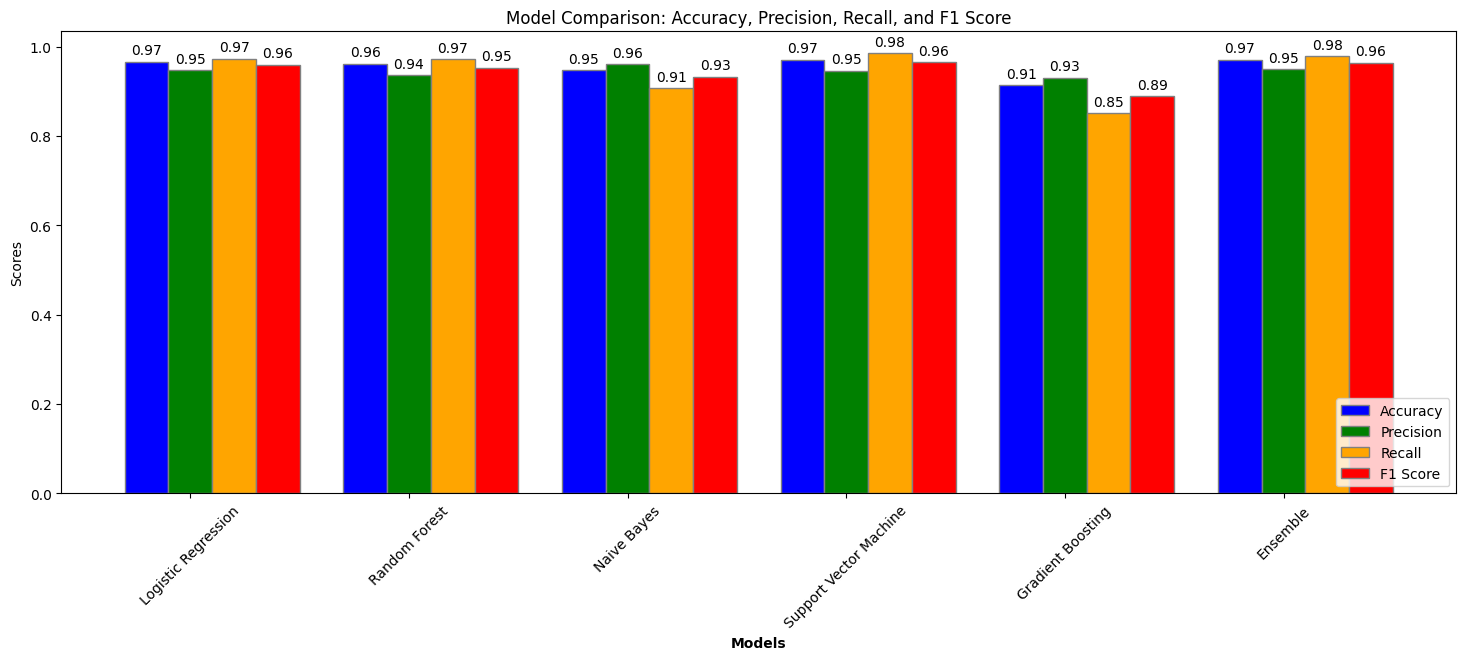

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Define model names and metrics
model_names = list(accuracy_scores.keys())
accuracies = list(accuracy_scores.values())
precisions = list(precision_scores.values())
recalls = list(recall_scores.values())
f1s = list(f1_scores.values())

# Set width and positions for bars
bar_width = 0.2
r1 = np.arange(len(model_names))
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]
r4 = [x + bar_width for x in r3]

# Plot grouped bar chart
plt.figure(figsize=(18, 6))
bars1 = plt.bar(r1, accuracies, color='blue', width=bar_width, edgecolor='grey', label='Accuracy')
bars2 = plt.bar(r2, precisions, color='green', width=bar_width, edgecolor='grey', label='Precision')
bars3 = plt.bar(r3, recalls, color='orange', width=bar_width, edgecolor='grey', label='Recall')
bars4 = plt.bar(r4, f1s, color='red', width=bar_width, edgecolor='grey', label='F1 Score')

# Add labels and title
plt.xlabel('Models', fontweight='bold')
plt.xticks([r + bar_width for r in range(len(model_names))], model_names, rotation=45)
plt.ylabel('Scores')
plt.title('Model Comparison: Accuracy, Precision, Recall, and F1 Score')

# Add legend
plt.legend(loc="lower right")

def add_labels(bars):
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.2f}", ha="center", va="bottom")

# Apply labels to each set of bars
add_labels(bars1)
add_labels(bars2)
add_labels(bars3)
add_labels(bars4)

# Show the plot
plt.show()